In [41]:
import os
import shap
import pickle
import joblib
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score
from sklearn.inspection import permutation_importance
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV

### Logistic Regression Model

In [ ]:
train_woe_trans_data = pd.read_parquet(
    "../data/processed/train_woe_output.parquet"
)

In [ ]:
train_df, test_df = train_test_split(
    train_woe_trans_data,
    test_size=0.2,
    random_state=0,
    shuffle=True
)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

In [ ]:
train_df.head(3)

In [ ]:
test_df.head(3)

In [ ]:
X_train = train_df.loc[:, ~train_df.columns.isin(["acct_id", "f_dpd_90plus_nxt_2yrs"])].copy()
y_train = train_df.loc[:, ["f_dpd_90plus_nxt_2yrs"]].copy()

X_test = test_df.loc[:, ~test_df.columns.isin(["acct_id", "f_dpd_90plus_nxt_2yrs"])].copy()
y_test = test_df.loc[:, ["f_dpd_90plus_nxt_2yrs"]].copy()

X_train = X_train.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)

X_test = X_test.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

In [ ]:
X_train.head(3)

In [ ]:
y_train.head(3)

In [ ]:
def compute_vif(X: pd.DataFrame) -> pd.DataFrame:
    vif_data = pd.DataFrame()
    vif_data["feature"] = X.columns
    vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    return vif_data

In [ ]:
compute_vif(X_train)

In [ ]:
def backward_elimination(
    X: pd.DataFrame,
    y: pd.Series,
    significance_level: float = 0.05,
    vif_threshold: float = 5
):
    """
    Perform backward elimination with VIF check and Gini tracking.
    """
    X = sm.add_constant(X, has_constant="add")
    variables = list(X.columns)

    while True:
        # Fit logistic regression with current variables
        model = sm.Logit(y, X[variables]).fit(disp=0)
        y_pred = model.predict(X[variables])
        auc = roc_auc_score(y, y_pred)
        gini = 2 * auc - 1
        print(f"\nCurrent variables: {variables}")
        print(f"Gini: {gini:.4f}")

        # Compute VIF excluding constant
        vif = compute_vif(X[variables].drop(columns="const", errors="ignore"))
        print("VIF values:")
        print(vif)

        # Print p-values
        print("P-values:")
        print(model.pvalues)

        # Step 1: Drop variable with highest VIF if > threshold
        max_vif = vif["VIF"].max()
        if max_vif > vif_threshold:
            excluded_var = vif.loc[vif["VIF"].idxmax(), "feature"]
            variables.remove(excluded_var)
            print(f"Removing {excluded_var} due to high VIF ({max_vif:.2f})\n")
            continue

        # Step 2: Drop variable with highest p-value if > significance_level
        p_values = model.pvalues.drop("const", errors="ignore")
        max_pval = p_values.max()
        if max_pval > significance_level:
            excluded_var = p_values.idxmax()
            variables.remove(excluded_var)
            print(f"Removing {excluded_var} with p-value {max_pval:.4f}\n")
        else:
            break

    return model

In [ ]:
bkwelm_best_model = backward_elimination(X_train, y_train)

In [ ]:
bkwelm_best_model.summary()

#### Evaluation on Test Data

In [ ]:
X_test.head(3)

In [ ]:
# Predict probabilities on test set
X_test_const = sm.add_constant(X_test)
y_test_pred = bkwelm_best_model.predict(X_test_const)

auc = roc_auc_score(y_test, y_test_pred)
gini = 2 * auc - 1
print(100 * gini)

In [ ]:
y_test = pd.Series(y_test["f_dpd_90plus_nxt_2yrs"])
y_test = y_test.reset_index(drop=True)
y_test_pred = y_test_pred.reset_index(drop=True)

In [ ]:
def plot_cap(y_true, y_pred, title):
    total = len(y_true)
    class_1_count = np.sum(y_true)

    sorted_indices = np.argsort(y_pred)[::-1]
    y_true_sorted = y_true[sorted_indices]

    cum_pos = np.cumsum(y_true_sorted)

    x_values = np.arange(1, total+1) / total
    y_values = cum_pos / class_1_count

    plt.plot([0,1], [0,1], linestyle='--', color='grey', label="Random Model")
    plt.plot([0, class_1_count/total, 1], [0,1,1], linestyle='--', color='green', label="Perfect Model")

    # Your model CAP curve
    plt.plot(x_values, y_values, color='blue', label="Model")

    plt.title(title)
    plt.xlabel("Proportion of data (sorted by score)")
    plt.ylabel("Proportion of positives captured")
    plt.legend()
    plt.grid(True)
    plt.show()

In [ ]:
plot_cap(
    y_test,
    y_test_pred,
    title = "CAP Curve - Logistic Regression Model"
)

### Save Logit, Preprocessing & WOE Parameters to Disk

In [ ]:
# model_path = "../models/logit_model.pkl"

# with open(model_path, "wb") as f:
#     pickle.dump(bkwelm_best_model, f)

# print("Model saved successfully!")

In [ ]:
# with open("../models/logit_model.pkl", "rb") as f:
#     logit_model = pickle.load(f)

# print(logit_model.model.exog_names)

In [ ]:
# preprocessing_params = {
#     "imputation_values": {
#         "monthly_income": 5400.0
#     },

#     "special_value_replacements": {
#         "age": {
#             0: 52.0
#         },

#         "n_dpd_90plus_hist": {
#             96: 0.0,
#             98: 0.0
#         },

#         "n_dpd_30_50_l2yrs": {
#             96: 0.0,
#             98: 0.0
#         }
#     }
# }

# preprocessing_params_path = "../models/preprocessing_params.pkl"

# with open(preprocessing_params_path, "wb") as f:
#     pickle.dump(preprocessing_params, f)

# print("Preprocessing params saved successfully!")

### XGBoost Model

In [2]:
train_data = pd.read_parquet(
    "../data/processed/train_eda_output.parquet"
)

In [3]:
train_data.head(3)

,acct_id,n_mort_loans,n_credit_lines,avg_util_unsec,debt_income_ratio,f_dpd_90plus_nxt_2yrs,n_dependents_nan_flag,monthly_income_nan_flag,n_dependents_imp,monthly_income_imp,n_dpd_90plus_hist_imp,n_dpd_60_89_l2yrs_imp,n_dpd_30_50_l2yrs_imp,age_imp
0,id_1,6,13,0.766127,0.802982,1,0,0,2.0,9120.0,0,0,2,45
1,id_2,0,4,0.957151,0.121876,0,0,0,1.0,2600.0,0,0,0,40
2,id_3,0,2,0.658180,0.085113,0,0,0,0.0,3042.0,1,0,1,38


In [4]:
X = train_data.loc[:, ~train_data.columns.isin(
    ["acct_id", "f_dpd_90plus_nxt_2yrs"]
)]

y = train_data.loc[:, ["f_dpd_90plus_nxt_2yrs"]]

In [5]:
display(X.head(3))
display(y.head(3))

,n_mort_loans,n_credit_lines,avg_util_unsec,debt_income_ratio,n_dependents_nan_flag,monthly_income_nan_flag,n_dependents_imp,monthly_income_imp,n_dpd_90plus_hist_imp,n_dpd_60_89_l2yrs_imp,n_dpd_30_50_l2yrs_imp,age_imp
0,6,13,0.766127,0.802982,0,0,2.0,9120.0,0,0,2,45
1,0,4,0.957151,0.121876,0,0,1.0,2600.0,0,0,0,40
2,0,2,0.658180,0.085113,0,0,0.0,3042.0,1,0,1,38


,f_dpd_90plus_nxt_2yrs
0,1
1,0
2,0


In [6]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

del X_temp, y_temp

In [7]:
print(X.shape)
print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(150000, 12)
(105000, 12)
(22500, 12)
(22500, 12)


In [8]:
display(X_train.head(3))
display(X_val.head(3))
display(X_test.head(3))

,n_mort_loans,n_credit_lines,avg_util_unsec,debt_income_ratio,n_dependents_nan_flag,monthly_income_nan_flag,n_dependents_imp,monthly_income_imp,n_dpd_90plus_hist_imp,n_dpd_60_89_l2yrs_imp,n_dpd_30_50_l2yrs_imp,age_imp
138985,0,5,0.000000,0.127227,0,0,0.0,5163.0,0,0,0,49
63964,1,4,0.033105,0.423063,0,0,1.0,2800.0,0,0,0,37
46077,1,11,0.007948,0.685663,0,0,0.0,3333.0,0,0,0,39


,n_mort_loans,n_credit_lines,avg_util_unsec,debt_income_ratio,n_dependents_nan_flag,monthly_income_nan_flag,n_dependents_imp,monthly_income_imp,n_dpd_90plus_hist_imp,n_dpd_60_89_l2yrs_imp,n_dpd_30_50_l2yrs_imp,age_imp
24377,1,14,0.400263,0.349646,0,0,3.0,8050.0,0,0,0,49
77974,0,0,1.000000,0.000000,0,1,0.0,5400.0,1,0,0,37
23941,1,7,0.727199,0.273762,0,0,0.0,5975.0,0,1,5,81


,n_mort_loans,n_credit_lines,avg_util_unsec,debt_income_ratio,n_dependents_nan_flag,monthly_income_nan_flag,n_dependents_imp,monthly_income_imp,n_dpd_90plus_hist_imp,n_dpd_60_89_l2yrs_imp,n_dpd_30_50_l2yrs_imp,age_imp
8576,2,11,0.950161,1.398001,0,0,0.0,2200.0,0,0,0,28
94519,0,1,0.021330,4.000000,0,1,0.0,5400.0,0,0,0,44
134921,0,2,1.000000,0.076208,0,0,0.0,2151.0,0,0,2,46


#### Variable Reduction

In [9]:
# model = XGBClassifier(
#     n_estimators=400,
#     learning_rate=0.05,
#     max_depth=5,
#     random_state=42,
#     eval_metric="auc",
#     early_stopping_rounds=50
# )

# model.fit(
#     X_train,
#     y_train,
#     eval_set=[(X_val, y_val)],
#     verbose=False
# )

# print(model.best_iteration)

In [10]:
# gain_importance = model.get_booster().get_score(
#     importance_type="gain"
# )

# gain_df = (
#     pd.DataFrame(
#         gain_importance.items(),
#         columns=["feature", "gain"]
#     )
#     .sort_values("gain", ascending=False)
#     .reset_index(drop=True)
# )

# gain_df

In [11]:
# explainer = shap.TreeExplainer(model)
# shap_values = explainer(X_train)

In [12]:
# shap_importance = pd.DataFrame({
#     "feature": X_train.columns,
#     "mean_abs_shap": abs(shap_values.values).mean(axis=0)
# })

# shap_importance = shap_importance.sort_values(
#     "mean_abs_shap",
#     ascending=False
# ).reset_index(drop=True)

# shap_importance

In [13]:
# perm_result = permutation_importance(
#     model,
#     X_val,
#     y_val,
#     scoring="roc_auc",
#     n_repeats=10,
#     random_state=42,
#     n_jobs=-1
# )

# perm_df = pd.DataFrame({
#     "feature": X_val.columns,
#     "importance_mean": perm_result.importances_mean
#     # "importance_std": perm_result.importances_std
# }).sort_values(
#     "importance_mean",
#     ascending=False
# ).reset_index(drop=True)

# perm_df

In [14]:
# useless_vars = ["n_dependents_imp", "monthly_income_imp", "monthly_income_nan_flag", "n_dependents_nan_flag"]

# X_train.drop(
#     columns = useless_vars,
#     inplace = True
# )

# X_val.drop(
#     columns = useless_vars,
#     inplace = True
# )

# X_test.drop(
#     columns = useless_vars,
#     inplace = True
# )

#### Hyperparameter Tuning

In [15]:
# model = XGBClassifier(
#     n_estimators=500,
#     learning_rate=0.05,

#     # Tree-level
#     max_depth=5,
#     min_child_weight=1,
#     gamma=0,

#     # Sampling
#     subsample=0.8,
#     colsample_bytree=0.8,

#     # Regularization
#     reg_alpha=0,
#     reg_lambda=0,

#     eval_metric="auc",
#     early_stopping_rounds=50,
#     random_state=42
# )

# model.fit(
#     X_train,
#     y_train,
#     eval_set=[(X_val, y_val)],
#     verbose=False
# )

In [16]:
# param_grid_tree = {
#     "max_depth": [3, 4, 5, 6, 7],
#     "min_child_weight": [1, 3, 5, 10]
#     # gamma = [0, 0.1, 0.5, 1, 2]
# }

# param_grid_samp = {
#     "subsample": [0.6, 0.7, 0.8, 0.9, 1.0],
#     "colsample_bytree": [0.6, 0.7, 0.8, 0.9, 1.0]
# }

# param_grid_reg = {
#     "reg_alpha": [0, 0.01, 0.1, 1],
#     "reg_lambda": [0.1, 1, 5, 10]
# }

In [17]:
# results = list()

# for max_depth in param_grid_tree["max_depth"]:
#     for min_child_weight in param_grid_tree["min_child_weight"]:

#         model = XGBClassifier(
#             n_estimators=500,
#             learning_rate=0.05,
#             max_depth=max_depth,
#             min_child_weight=min_child_weight,
#             eval_metric="auc",
#             early_stopping_rounds=50,
#             random_state=42
#         )

#         model.fit(
#             X_train,
#             y_train,
#             eval_set=[(X_val, y_val)],
#             verbose=False
#         )

#         val_auc = roc_auc_score(
#             y_val,
#             model.predict_proba(X_val)[:, 1]
#         )

#         results.append({
#             "max_depth": max_depth,
#             "min_child_weight": min_child_weight,
#             "best_iteration": model.best_iteration,
#             "val_auc": val_auc
#         })

In [18]:
# tree_params_result = pd.DataFrame(results)

# best_tree_params = (
#     tree_params_result.
#     loc[tree_params_result["val_auc"] == tree_params_result["val_auc"].max(), :]
# )
# display(best_tree_params)

In [19]:
# results = list()

# for subsample in param_grid_samp["subsample"]:
#     for colsample_bytree in param_grid_samp["colsample_bytree"]:

#         model = XGBClassifier(
#             n_estimators=500,
#             learning_rate=0.05,
#             max_depth = 4,
#             min_child_weight = 3,
#             subsample=subsample,
#             colsample_bytree=colsample_bytree,
#             eval_metric="auc",
#             early_stopping_rounds=30,
#             random_state=42
#         )

#         model.fit(
#             X_train,
#             y_train,
#             eval_set=[(X_val, y_val)],
#             verbose=False
#         )

#         val_auc = roc_auc_score(
#             y_val,
#             model.predict_proba(X_val)[:, 1]
#         )

#         results.append({
#             "subsample": subsample,
#             "colsample_bytree": colsample_bytree,
#             "best_iteration": model.best_iteration,
#             "val_auc": val_auc
#         })

In [20]:
# sample_params_result = (
#     pd.DataFrame(results)
#     .sort_values("val_auc", ascending=False)
#     .reset_index(drop=True)
# )

# best_sample_params = sample_params_result.iloc[0]
# display(best_sample_params)

In [21]:
# results = list()

# for reg_alpha in param_grid_reg["reg_alpha"]:
#     for reg_lambda in param_grid_reg["reg_lambda"]:

#         model = XGBClassifier(
#             n_estimators=500,
#             learning_rate=0.05,
#             max_depth=4,
#             min_child_weight=3,
#             subsample=0.8,
#             colsample_bytree=0.7,
#             reg_alpha=reg_alpha,
#             reg_lambda=reg_lambda,
#             eval_metric="auc",
#             early_stopping_rounds=30,
#             random_state=42
#         )

#         model.fit(
#             X_train,
#             y_train,
#             eval_set=[(X_val, y_val)],
#             verbose=False
#         )

#         val_auc = roc_auc_score(
#             y_val,
#             model.predict_proba(X_val)[:, 1]
#         )

#         results.append({
#             "reg_alpha": reg_alpha,
#             "reg_lambda": reg_lambda,
#             "best_iteration": model.best_iteration,
#             "val_auc": val_auc
#         })

In [22]:
# reg_params_result = (
#     pd.DataFrame(results)
#     .sort_values("val_auc", ascending=False)
#     .reset_index(drop=True)
# )

# best_reg_params = reg_params_result.iloc[0]
# display(best_reg_params)

#### Final Model

In [23]:
useless_vars = ["n_dependents_imp", "monthly_income_imp", "monthly_income_nan_flag", "n_dependents_nan_flag"]

X_train.drop(
    columns = useless_vars,
    inplace = True
)

X_val.drop(
    columns = useless_vars,
    inplace = True
)

X_test.drop(
    columns = useless_vars,
    inplace = True
)

In [24]:
model = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.7,
    reg_alpha=0.1,
    reg_lambda=1.0,
    eval_metric="auc",
    early_stopping_rounds=30,
    random_state=42
)

model.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

train_auc = roc_auc_score(
    y_train,
    model.predict_proba(X_train)[:, 1]
)

val_auc = roc_auc_score(
    y_val,
    model.predict_proba(X_val)[:, 1]
)

test_auc = roc_auc_score(
    y_test,
    model.predict_proba(X_test)[:, 1]
)

print("AUC ROC on train set:", train_auc)
print("AUC ROC on valdn set:", val_auc)
print("AUC ROC on test set:", test_auc)

AUC ROC on train set: 0.8776314083174231
AUC ROC on valdn set: 0.8700551466490071
AUC ROC on test set: 0.8614987422882981


best iternation: 405


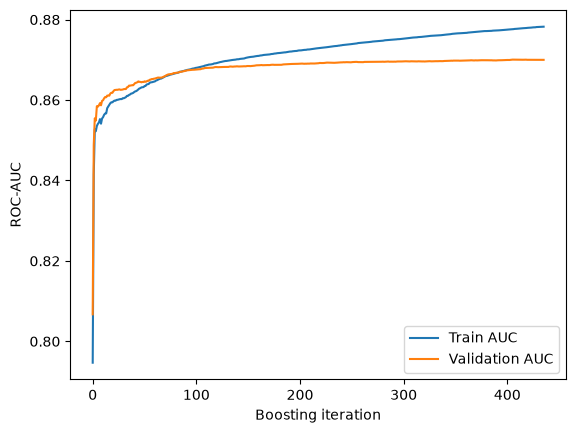

In [25]:
#learning curve - to rule out overfitting

model.fit(
    X_train,
    y_train,
    eval_set=[
        (X_train, y_train),
        (X_val, y_val)
    ],
    verbose=False
)

results = model.evals_result()

train_auc = results["validation_0"]["auc"]
val_auc = results["validation_1"]["auc"]

print("best iternation:", model.best_iteration)

plt.plot(train_auc, label="Train AUC")
plt.plot(val_auc, label="Validation AUC")
plt.xlabel("Boosting iteration")
plt.ylabel("ROC-AUC")
plt.legend()
plt.show()

In [26]:
X_train_val = pd.concat([X_train, X_val], axis=0)
y_train_val = pd.concat([y_train, y_val], axis=0)

xgb_model = XGBClassifier(
    n_estimators=405,
    learning_rate=0.05,
    max_depth=4,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.7,
    reg_alpha=0.1,
    reg_lambda=1.0,
    eval_metric="auc",
    early_stopping_rounds=30,
    random_state=42
)

xgb_model.fit(
    X_train_val,
    y_train_val,
    eval_set=[(X_val, y_val)],
    verbose=False
)

train_vald_auc = roc_auc_score(
    y_train_val,
    xgb_model.predict_proba(X_train_val)[:, 1]
)

test_auc = roc_auc_score(
    y_test,
    xgb_model.predict_proba(X_test)[:, 1]
)

print("AUC - Train_valdn Set:", train_vald_auc)
print("AUC - Test Set:", test_auc)

AUC - Train_valdn Set: 0.8770510912406545
AUC - Test Set: 0.8613478460182893


In [27]:
X_train_val.head(3)

,n_mort_loans,n_credit_lines,avg_util_unsec,debt_income_ratio,n_dpd_90plus_hist_imp,n_dpd_60_89_l2yrs_imp,n_dpd_30_50_l2yrs_imp,age_imp
138985,0,5,0.000000,0.127227,0,0,0,49
63964,1,4,0.033105,0.423063,0,0,0,37
46077,1,11,0.007948,0.685663,0,0,0,39


In [28]:
# n_mort_loans - added
# n_credit_lines - added
# avg_util_unsec - existing
# debt_income_ratio - existing
# n_dpd_90plus_hist_imp - existing
# n_dpd_60_89_l2yrs_imp - added
# n_dpd_30_50_l2yrs_imp - existing
# age_imp - existing
# monthly_income - removed

In [29]:
from pathlib import Path

model_path = Path("../models/xgb_model.json")

# --------------------
# Save model
# --------------------
if model_path.exists():
    print("XGBoost model already exists.")
else:
    model_path.parent.mkdir(
        parents=True, 
        exist_ok=True
    )
    xgb_model.save_model(model_path)
    print("XGBoost model saved successfully.")

XGBoost model already exists.


In [30]:
model_path = Path("../models/xgb_model.json")

# --------------------
# Load model
# --------------------
if model_path.exists():
    xgb_model = XGBClassifier()
    xgb_model.load_model(model_path)
    print("XGBoost model loaded successfully.")
else:
    print("XGBoost model does not exist.")

XGBoost model loaded successfully.


In [31]:
xgb_model

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",[0.06683922]
,booster,'gbtree'
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,"['int', 'int', ...]"


#### Model Explaination

In [ ]:
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer(X_train_val)

In [33]:
shap_importance_temp = pd.DataFrame({
    "feature": X_train_val.columns,
    "mean_abs_shap": abs(shap_values.values).mean(axis=0)
})

shap_importance = (
    shap_importance_temp
    .sort_values("mean_abs_shap", ascending=False)
    .reset_index(drop=True)
)

display(shap_importance)

,feature,mean_abs_shap
0,avg_util_unsec,0.771521
1,n_dpd_30_50_l2yrs_imp,0.346418
2,n_dpd_90plus_hist_imp,0.316395
3,age_imp,0.231537
4,n_dpd_60_89_l2yrs_imp,0.182490
5,n_credit_lines,0.160166
6,debt_income_ratio,0.152303
7,n_mort_loans,0.123754


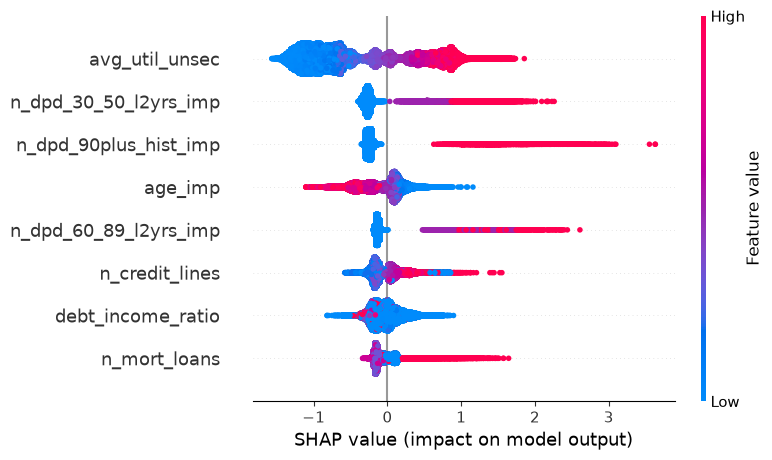

In [34]:
shap.summary_plot(
    shap_values,
    X_train_val
)

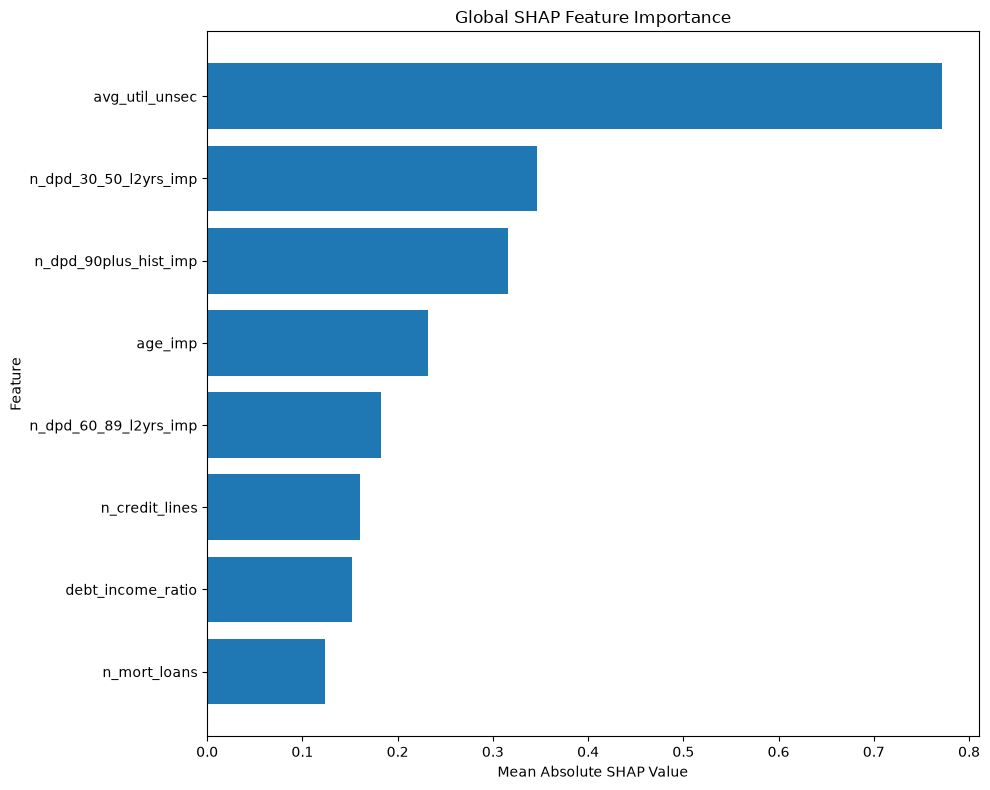

In [35]:
plt.figure(figsize=(10, 8))

plt.barh(
    shap_importance["feature"],
    shap_importance["mean_abs_shap"]
)

plt.xlabel("Mean Absolute SHAP Value")
plt.ylabel("Feature")
plt.title("Global SHAP Feature Importance")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [36]:
X_train_val.head(3)

,n_mort_loans,n_credit_lines,avg_util_unsec,debt_income_ratio,n_dpd_90plus_hist_imp,n_dpd_60_89_l2yrs_imp,n_dpd_30_50_l2yrs_imp,age_imp
138985,0,5,0.000000,0.127227,0,0,0,49
63964,1,4,0.033105,0.423063,0,0,0,37
46077,1,11,0.007948,0.685663,0,0,0,39


In [37]:
new_customer = pd.DataFrame({
    "n_mort_loans": [1],
    "n_credit_lines": [7],
    "avg_util_unsec": [0.65],
    "debt_income_ratio": [0.40],
    "n_dpd_90plus_hist_imp": [1],
    "n_dpd_60_89_l2yrs_imp": [0],
    "n_dpd_30_50_l2yrs_imp": [2],
    "age_imp": [35]
})

In [38]:
pd = xgb_model.predict_proba(new_customer)[:, 1][0]
print(pd)

0.4193742


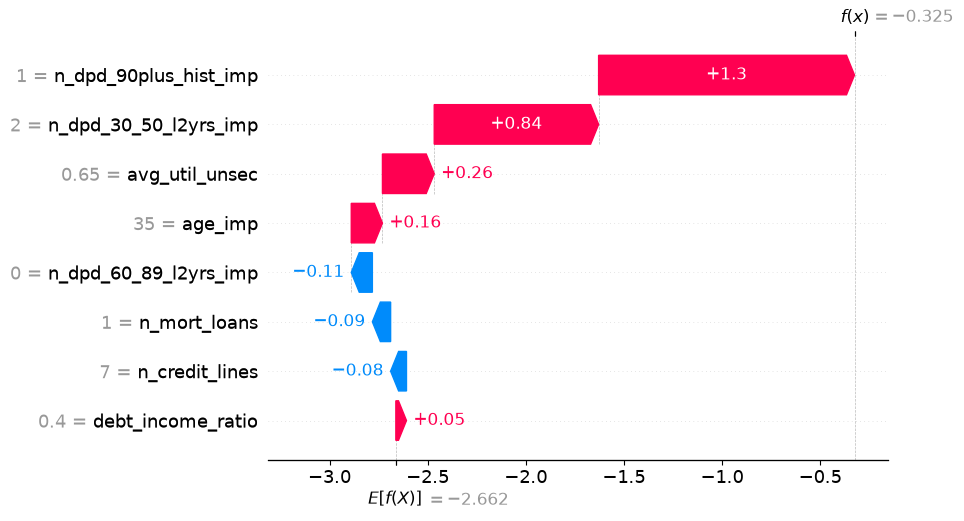

None

In [39]:
shap_values = explainer(new_customer)
display(shap.plots.waterfall(shap_values[0]))

In [42]:
explainer_path = Path("../models/shap_explainer.pkl")

if explainer_path.exists():
    print("SHAP explainer already exists.")
else:
    shap_explainer = shap.TreeExplainer(xgb_model)
    joblib.dump(shap_explainer, explainer_path)
    print("SHAP explainer saved successfully.")

SHAP explainer saved successfully.


In [44]:
if explainer_path.exists():
    shap_explainer = joblib.load(explainer_path)
    print("SHAP explainer loaded successfully.")
else:
    print("SHAP explainer does not exist. Please create and save it first.")

SHAP explainer loaded successfully.


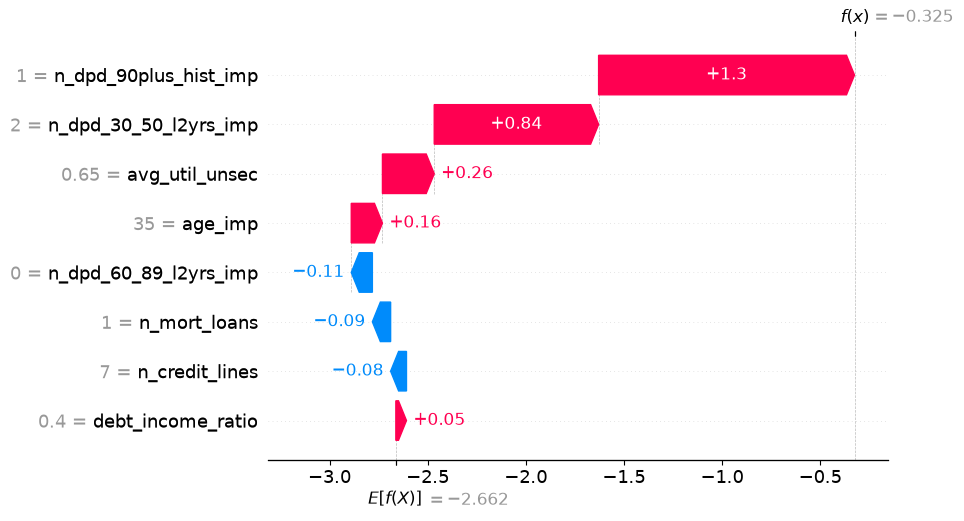

In [45]:
shap_values = shap_explainer(new_customer)
shap.plots.waterfall(shap_values[0])